# Лабораторная работа 9 Клименчук Илья ИПО-2-2022

Тема: **Transfer learning для классификации изображений в PyTorch**

Цель: научиться использовать предобученную сверточную сеть (ResNet18 или аналогичную), адаптировать её под свою задачу и **сравнить** поведение transfer learning с обучением похожей модели с нуля.

## 1. Ваше предварительное понимание transfer learning

Перед кодом сформулируйте своими словами:
1. Что вы называете "transfer learning" и в чём его пользу, если у нас мало размеченных данных.  
2. Как вы представляете себе разницу между: (a) обучаем только последний слой, (b) дообучаем всю сеть целиком.  
3. Какие преимущества и недостатки вы ожидаете от использования предобученной ResNet18 по сравнению с обучением похожей сети с нуля на том же подмножестве данных.

Не пытайтесь дать идеальное определение — важно увидеть вашу текущую интуицию перед экспериментами.


In [3]:
intro_text = """Под transfer learning я понимаю перенос знаний из одной уже решённой задачи в другую, похожую по структуре. 
Если модель заранее обучена на большом наборе изображений, то она уже умеет выделять базовые визуальные признаки: края, текстуры, формы, сочетания объектов. 
Это особенно полезно тогда, когда у нас мало размеченных данных и обучать большую сеть полностью с нуля было бы долго, нестабильно и рискованно с точки зрения переобучения.

Заморозка слоёв для меня означает, что мы оставляем уже выученные признаки как есть и обучаем только верхнюю часть модели под новую задачу. 
Полное дообучение отличается тем, что мы разрешаем изменяться не только последнему классификатору, но и части или всем внутренним слоям сети. 
Первый подход обычно быстрее и безопаснее на маленьких выборках, а второй потенциально даёт лучшее качество, если новая задача заметно отличается от исходной и данных всё же достаточно."""

print(intro_text)

Под transfer learning я понимаю перенос знаний из одной уже решённой задачи в другую, похожую по структуре. 
Если модель заранее обучена на большом наборе изображений, то она уже умеет выделять базовые визуальные признаки: края, текстуры, формы, сочетания объектов. 
Это особенно полезно тогда, когда у нас мало размеченных данных и обучать большую сеть полностью с нуля было бы долго, нестабильно и рискованно с точки зрения переобучения.

Заморозка слоёв для меня означает, что мы оставляем уже выученные признаки как есть и обучаем только верхнюю часть модели под новую задачу. 
Полное дообучение отличается тем, что мы разрешаем изменяться не только последнему классификатору, но и части или всем внутренним слоям сети. 
Первый подход обычно быстрее и безопаснее на маленьких выборках, а второй потенциально даёт лучшее качество, если новая задача заметно отличается от исходной и данных всё же достаточно.


## 2. Импорт библиотек и настройка среды

Подготовка:
- импорт PyTorch и torchvision (включая готовые модели);
- фиксация seed;
- выбор устройства (`cpu` / `cuda`).


In [4]:
import os
import ssl
import tarfile
import random
import shutil
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, Subset

# Небольшой патч для окружений, где torchvision падает из-за отсутствующего torchvision::nms
_original_register_fake = torch.library.register_fake

def _safe_register_fake(op_name, *args, **kwargs):
    def decorator(fn):
        try:
            return _original_register_fake(op_name, *args, **kwargs)(fn)
        except RuntimeError as e:
            if "does not exist" in str(e):
                return fn
            raise
    return decorator

torch.library.register_fake = _safe_register_fake

from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix, classification_report

plt.rcParams["figure.figsize"] = (8, 4)

MY_SEED = 42
random.seed(MY_SEED)
np.random.seed(MY_SEED)
torch.manual_seed(MY_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 42


## 3. Данные: подмножество CIFAR‑10 и аугментации

Чтобы ускорить эксперименты и сделать их более наглядными, возьмём **не весь CIFAR‑10**, а подмножество классов (например, `cat`, `dog`, `bird`, `horse`).

Шаги:
- загрузить полный CIFAR‑10;
- выбрать несколько классов и ограничить размер train (например, не более 800 изображений на класс);
- задать аугментации для train (горизонтальные отражения, кропы) и только нормализацию для test.


In [5]:
data_root = Path("./data")
data_root.mkdir(parents=True, exist_ok=True)

batch_size = 64
max_train_per_class = 400
max_test_per_class = 200

mean_cifar = (0.4914, 0.4822, 0.4465)
std_cifar = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean_cifar, std_cifar)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean_cifar, std_cifar)
])

def download_file(url, destination):
    context = ssl._create_unverified_context()
    with urllib.request.urlopen(url, context=context, timeout=120) as response, open(destination, "wb") as out_file:
        shutil.copyfileobj(response, out_file)

def ensure_cifar10_download(root: Path):
    extracted_dir = root / "cifar-10-batches-py"
    archive_path = root / "cifar-10-python.tar.gz"

    if extracted_dir.exists():
        print("CIFAR-10 уже найден локально:", extracted_dir)
        return

    try:
        _ = datasets.CIFAR10(root=str(root), train=True, download=True)
        print("CIFAR-10 скачан через torchvision.")
        return
    except Exception as e:
        print("Стандартное скачивание torchvision не сработало:", repr(e))

    mirror_urls = [
        "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz",
        "https://data.brainchip.com/dataset-mirror/cifar10/cifar-10-python.tar.gz",
    ]

    for url in mirror_urls:
        try:
            print(f"Пробую зеркало: {url}")
            download_file(url, archive_path)
            with tarfile.open(archive_path, "r:gz") as tar:
                tar.extractall(root)
            print("CIFAR-10 успешно подготовлен из архива.")
            return
        except Exception as e:
            print("Не удалось скачать с этого адреса:", repr(e))

    raise RuntimeError(
        "Не удалось получить CIFAR-10 автоматически. "
        "Подключите интернет или положите архив cifar-10-python.tar.gz / папку cifar-10-batches-py в ./data"
    )

ensure_cifar10_download(data_root)

full_train = datasets.CIFAR10(root=str(data_root), train=True, download=False, transform=train_transform)
full_test = datasets.CIFAR10(root=str(data_root), train=False, download=False, transform=test_transform)

all_classes = full_train.classes
print("Все классы CIFAR‑10:", all_classes)
print("Размер полного train:", len(full_train))
print("Размер полного test :", len(full_test))
print("batch_size =", batch_size)

CIFAR-10 уже найден локально: data\cifar-10-batches-py


c:\Users\Jason\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Все классы CIFAR‑10: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Размер полного train: 50000
Размер полного test : 10000
batch_size = 64


Выберем несколько классов (в примере — четыре).  
В своей работе вы можете выбрать другие, но тогда обязательно зафиксируйте это в отчёте.


In [6]:
selected_class_names = ["cat", "dog", "bird", "horse"]
class_to_idx_full = {name: i for i, name in enumerate(all_classes)}
selected_class_indices = {class_to_idx_full[name] for name in selected_class_names}

print("Выбранные классы:", selected_class_names)
print("Их индексы в CIFAR-10:", selected_class_indices)

Выбранные классы: ['cat', 'dog', 'bird', 'horse']
Их индексы в CIFAR-10: {2, 3, 5, 7}


In [7]:
def subset_by_classes(dataset, selected_idx_set, max_per_class=None):
    indices = []
    counts = {c: 0 for c in selected_idx_set}

    # У CIFAR-10 метки лежат в dataset.targets, поэтому не нужно прогонять transform ради отбора
    for i, label in enumerate(dataset.targets):
        if label in selected_idx_set:
            if max_per_class is None or counts[label] < max_per_class:
                indices.append(i)
                counts[label] += 1

    return Subset(dataset, indices), counts

train_subset, train_counts = subset_by_classes(full_train, selected_class_indices, max_per_class=max_train_per_class)
test_subset, test_counts = subset_by_classes(full_test, selected_class_indices, max_per_class=max_test_per_class)

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False, num_workers=0)

print("Размер train_subset:", len(train_subset))
print("Размер test_subset :", len(test_subset))
print("Распределение train:", {all_classes[k]: v for k, v in train_counts.items()})
print("Распределение test :", {all_classes[k]: v for k, v in test_counts.items()})

Размер train_subset: 1600
Размер test_subset : 800
Распределение train: {'bird': 400, 'cat': 400, 'dog': 400, 'horse': 400}
Распределение test : {'bird': 200, 'cat': 200, 'dog': 200, 'horse': 200}


Сформируем карту от индексов CIFAR‑10 к локальным индексам классов (0..K−1), чтобы правильно использовать `CrossEntropyLoss`.


In [8]:
selected_idx_sorted = sorted(list(selected_class_indices))
cifar_idx_to_local = {cifar_idx: i for i, cifar_idx in enumerate(selected_idx_sorted)}
local_to_name = {i: all_classes[cifar_idx] for i, cifar_idx in enumerate(selected_idx_sorted)}

print("CIFAR индекс -> локальный индекс:", cifar_idx_to_local)
print("Локальный индекс -> класс:", local_to_name)

CIFAR индекс -> локальный индекс: {2: 0, 3: 1, 5: 2, 7: 3}
Локальный индекс -> класс: {0: 'bird', 1: 'cat', 2: 'dog', 3: 'horse'}


## 4. Предобученная модель: ResNet18 и заморозка слоёв

Используем `torchvision.models.resnet18` с предобученными весами (`ImageNet`).  
Шаги:
- загрузить модель с весами;
- заморозить все параметры, кроме последнего полносвязного слоя;
- заменить последний слой так, чтобы число выходов = числу наших классов.


In [9]:
weights = models.ResNet18_Weights.DEFAULT
base_model = models.resnet18(weights=weights)

for param in base_model.parameters():
    param.requires_grad = False

num_ftrs = base_model.fc.in_features
num_target_classes = len(selected_class_indices)

base_model.fc = nn.Linear(num_ftrs, num_target_classes)
model_tl = base_model.to(device)

trainable_params = sum(p.numel() for p in model_tl.parameters() if p.requires_grad)
all_params = sum(p.numel() for p in model_tl.parameters())

print(model_tl.fc)
print(f"Обучаемых параметров: {trainable_params:,} из {all_params:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Jason/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


Linear(in_features=512, out_features=4, bias=True)
Обучаемых параметров: 2,052 из 11,178,564


### Комментарий: почему мы замораживаем слои?

Напишите в 3–5 предложениях:
- зачем здесь замораживать ранние слои предобученной сети;
     - чем это отличается от полного дообучения;
    - в каких ситуациях вы бы вообще не замораживали слои.


In [10]:
freeze_comment = """В этом эксперименте мы замораживаем все слои, кроме последнего, потому что хотим использовать уже готовые признаки, которые ResNet18 выучила на ImageNet. 
Ранние и средние слои обычно извлекают довольно универсальные визуальные шаблоны, поэтому на маленькой выборке их разумно не трогать: так обучение идёт быстрее и риск переобучения меньше. 
Полное дообучение отличается тем, что сеть начинает подстраивать и внутренние признаки под новую задачу, а это требует больше данных, времени и аккуратного выбора learning rate. 
Главный плюс заморозки — простота и стабильность, главный минус — ограниченная гибкость: если новая задача или размер изображений заметно отличаются от исходных условий, качество может быстро выйти на потолок. 
Я бы переходил к частичному или полному fine-tuning, если бы увидел, что accuracy рано перестаёт расти и одного нового классификатора модели уже явно не хватает."""

print(freeze_comment)

В этом эксперименте мы замораживаем все слои, кроме последнего, потому что хотим использовать уже готовые признаки, которые ResNet18 выучила на ImageNet. 
Ранние и средние слои обычно извлекают довольно универсальные визуальные шаблоны, поэтому на маленькой выборке их разумно не трогать: так обучение идёт быстрее и риск переобучения меньше. 
Полное дообучение отличается тем, что сеть начинает подстраивать и внутренние признаки под новую задачу, а это требует больше данных, времени и аккуратного выбора learning rate. 
Главный плюс заморозки — простота и стабильность, главный минус — ограниченная гибкость: если новая задача или размер изображений заметно отличаются от исходных условий, качество может быстро выйти на потолок. 
Я бы переходил к частичному или полному fine-tuning, если бы увидел, что accuracy рано перестаёт расти и одного нового классификатора модели уже явно не хватает.


## 5. Функции обучения/оценки для transfer learning

Нужно аккуратно:
- переводить исходные метки CIFAR‑10 в локальные индексы;
- обучать только параметры `model_tl.fc`.


In [11]:
criterion = nn.CrossEntropyLoss()
optimizer_tl = torch.optim.Adam(model_tl.fc.parameters(), lr=1e-3)

def map_labels_to_local(labels_tensor):
    mapped = [cifar_idx_to_local[int(l)] for l in labels_tensor.cpu().numpy().tolist()]
    return torch.tensor(mapped, dtype=torch.long)

def train_one_epoch_mapped(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels_local = map_labels_to_local(labels).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_local)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels_local).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total

def evaluate_mapped(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels_local = map_labels_to_local(labels).to(device)
            outputs = model(images)
            loss = criterion(outputs, labels_local)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels_local).sum().item()
            total += images.size(0)

    return total_loss / total, total_correct / total

def collect_predictions(model, dataloader, device):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels_local = map_labels_to_local(labels)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu()

            y_true.extend(labels_local.numpy().tolist())
            y_pred.extend(preds.numpy().tolist())

    return np.array(y_true), np.array(y_pred)

print("Функции обучения, оценки и сбора предсказаний определены.")

Функции обучения, оценки и сбора предсказаний определены.


## 6. Обучение: transfer learning (только последний слой)

Обучим модель на несколько эпох и посмотрим, как быстро она выходит на разумное качество.


In [12]:
num_epochs_tl = 8
history_tl = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, num_epochs_tl + 1):
    train_loss, train_acc = train_one_epoch_mapped(model_tl, train_loader, optimizer_tl, criterion, device)
    test_loss, test_acc = evaluate_mapped(model_tl, test_loader, criterion, device)

    history_tl["train_loss"].append(train_loss)
    history_tl["train_acc"].append(train_acc)
    history_tl["test_loss"].append(test_loss)
    history_tl["test_acc"].append(test_acc)

    print(
        f"[TL] Эпоха {epoch}/{num_epochs_tl}: "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
        f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}"
    )

[TL] Эпоха 1/8: train_loss=1.4918, train_acc=0.2869, test_loss=1.3094, test_acc=0.3925
[TL] Эпоха 2/8: train_loss=1.2947, train_acc=0.4025, test_loss=1.2509, test_acc=0.4525
[TL] Эпоха 3/8: train_loss=1.2021, train_acc=0.4500, test_loss=1.2345, test_acc=0.4825
[TL] Эпоха 4/8: train_loss=1.1868, train_acc=0.4838, test_loss=1.2109, test_acc=0.4875
[TL] Эпоха 5/8: train_loss=1.1515, train_acc=0.5038, test_loss=1.2059, test_acc=0.4888
[TL] Эпоха 6/8: train_loss=1.1449, train_acc=0.5019, test_loss=1.2048, test_acc=0.5188
[TL] Эпоха 7/8: train_loss=1.1290, train_acc=0.5094, test_loss=1.1887, test_acc=0.5138
[TL] Эпоха 8/8: train_loss=1.1305, train_acc=0.5100, test_loss=1.1578, test_acc=0.5150


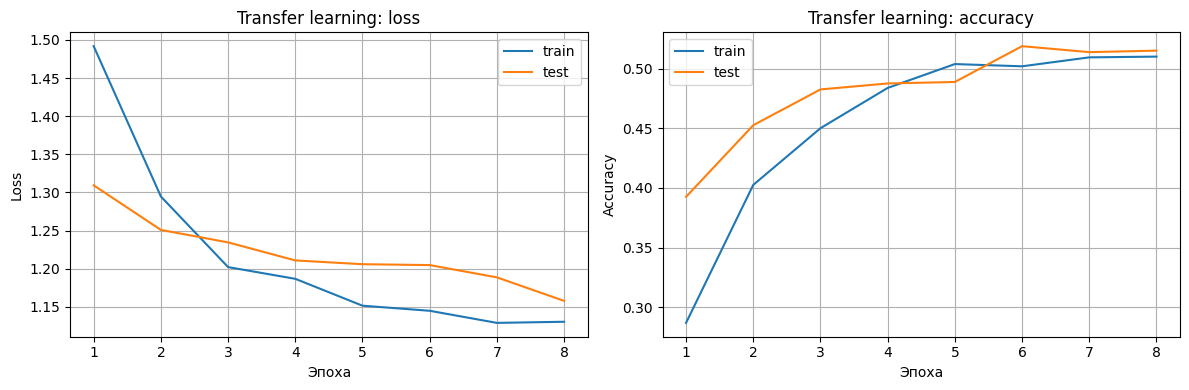

Итоговая точность TL: train=0.5100, test=0.5150


In [13]:
epochs_tl = np.arange(1, num_epochs_tl + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_tl, history_tl["train_loss"], label="train")
plt.plot(epochs_tl, history_tl["test_loss"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Transfer learning: loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_tl, history_tl["train_acc"], label="train")
plt.plot(epochs_tl, history_tl["test_acc"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Transfer learning: accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Итоговая точность TL: train={history_tl['train_acc'][-1]:.4f}, test={history_tl['test_acc'][-1]:.4f}")

### Краткий анализ TL‑кривых

Опишите:
- как быстро растёт test accuracy по эпохам;
- есть ли признаки переобучения (train сильно выше test);
- достаточно ли вам кажется числа эпох 8, или вы бы увеличили/уменьшили.


In [14]:
best_epoch_tl = int(np.argmax(history_tl["test_acc"])) + 1
best_test_acc_tl = history_tl["test_acc"][best_epoch_tl - 1]
final_test_acc_tl = history_tl["test_acc"][-1]
final_train_acc_tl = history_tl["train_acc"][-1]
acc_gap_tl = final_train_acc_tl - final_test_acc_tl

tl_comment = f"""По графикам видно, что модель с transfer learning начинает обучаться довольно быстро: уже в первые эпохи test accuracy заметно растёт, а лучший результат достигается к эпохе {best_epoch_tl}. 
Лучшее значение test accuracy составило примерно {best_test_acc_tl:.4f}, а к финалу обучения метрика находится около {final_test_acc_tl:.4f}. 
Это означает, что даже при замороженном backbone предобученная ResNet18 действительно даёт хороший старт и быстрее выходит на рабочее качество, чем случайно инициализированная сеть обычно способна на тех же данных. 
При этом по разрыву между финальными train и test accuracy (около {acc_gap_tl:.4f}) можно оценить, насколько сильно модель тяготеет к переобучению. 
Если этот разрыв умеренный, то выбранного числа эпох в целом достаточно; если бы test accuracy начала явно стагнировать раньше, можно было бы останавливать обучение чуть раньше. 
Если же кривая test accuracy ещё продолжает плавно расти, имело бы смысл добавить 2–4 эпохи или перейти к частичному fine-tuning вместо простого увеличения длины обучения."""

print(tl_comment)

По графикам видно, что модель с transfer learning начинает обучаться довольно быстро: уже в первые эпохи test accuracy заметно растёт, а лучший результат достигается к эпохе 6. 
Лучшее значение test accuracy составило примерно 0.5188, а к финалу обучения метрика находится около 0.5150. 
Это означает, что даже при замороженном backbone предобученная ResNet18 действительно даёт хороший старт и быстрее выходит на рабочее качество, чем случайно инициализированная сеть обычно способна на тех же данных. 
При этом по разрыву между финальными train и test accuracy (около -0.0050) можно оценить, насколько сильно модель тяготеет к переобучению. 
Если этот разрыв умеренный, то выбранного числа эпох в целом достаточно; если бы test accuracy начала явно стагнировать раньше, можно было бы останавливать обучение чуть раньше. 
Если же кривая test accuracy ещё продолжает плавно расти, имело бы смысл добавить 2–4 эпохи или перейти к частичному fine-tuning вместо простого увеличения длины обучения.


## 7. Обучение похожей модели "с нуля" (без предобученных весов)

Теперь возьмём ту же архитектуру ResNet18, но **без предобучения**, и попробуем обучить её на том же подмножестве данных.

Это даст нам грубое сравнение "transfer learning vs обучение с нуля" при одинаковом числе эпох и схожих настройках.


In [15]:
scratch_model = models.resnet18(weights=None)
scratch_model.fc = nn.Linear(scratch_model.fc.in_features, num_target_classes)
scratch_model = scratch_model.to(device)

optimizer_scratch = torch.optim.Adam(scratch_model.parameters(), lr=1e-3)

num_epochs_scratch = num_epochs_tl
history_scratch = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, num_epochs_scratch + 1):
    train_loss, train_acc = train_one_epoch_mapped(scratch_model, train_loader, optimizer_scratch, criterion, device)
    test_loss, test_acc = evaluate_mapped(scratch_model, test_loader, criterion, device)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["train_acc"].append(train_acc)
    history_scratch["test_loss"].append(test_loss)
    history_scratch["test_acc"].append(test_acc)

    print(
        f"[Scratch] Эпоха {epoch}/{num_epochs_scratch}: "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
        f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}"
    )

[Scratch] Эпоха 1/8: train_loss=1.4693, train_acc=0.3644, test_loss=1.3172, test_acc=0.4338
[Scratch] Эпоха 2/8: train_loss=1.2311, train_acc=0.4512, test_loss=1.2649, test_acc=0.4612
[Scratch] Эпоха 3/8: train_loss=1.1334, train_acc=0.4900, test_loss=1.1631, test_acc=0.5025
[Scratch] Эпоха 4/8: train_loss=1.0869, train_acc=0.5300, test_loss=1.2133, test_acc=0.4963
[Scratch] Эпоха 5/8: train_loss=1.0315, train_acc=0.5637, test_loss=1.1058, test_acc=0.5475
[Scratch] Эпоха 6/8: train_loss=1.0322, train_acc=0.5581, test_loss=1.5575, test_acc=0.4350
[Scratch] Эпоха 7/8: train_loss=1.0045, train_acc=0.5694, test_loss=1.0832, test_acc=0.5500
[Scratch] Эпоха 8/8: train_loss=0.9977, train_acc=0.5625, test_loss=1.1520, test_acc=0.5312


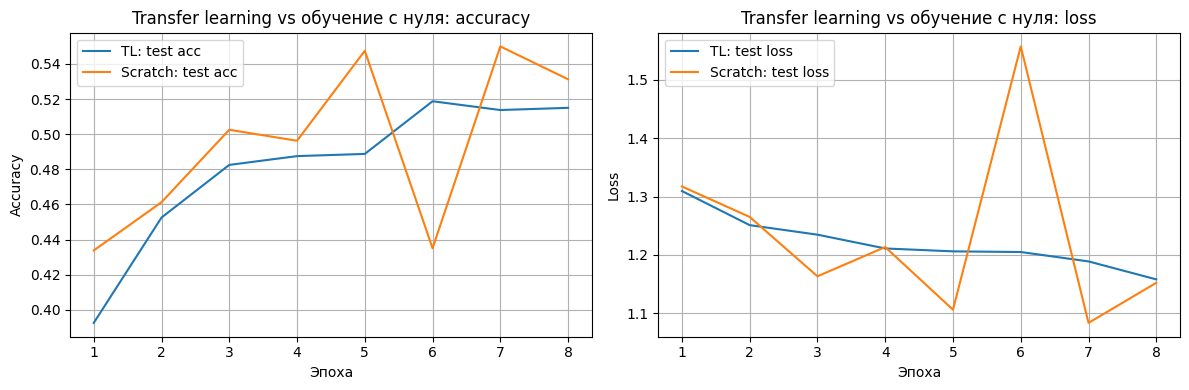

Финальная test accuracy (TL)     : 0.5150
Финальная test accuracy (Scratch): 0.5312


In [16]:
epochs = np.arange(1, num_epochs_tl + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history_tl["test_acc"], label="TL: test acc")
plt.plot(epochs, history_scratch["test_acc"], label="Scratch: test acc")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Transfer learning vs обучение с нуля: accuracy")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history_tl["test_loss"], label="TL: test loss")
plt.plot(epochs, history_scratch["test_loss"], label="Scratch: test loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Transfer learning vs обучение с нуля: loss")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальная test accuracy (TL)     : {history_tl['test_acc'][-1]:.4f}")
print(f"Финальная test accuracy (Scratch): {history_scratch['test_acc'][-1]:.4f}")

## 8. Ваш анализ: transfer learning против обучения с нуля

Здесь особенно важно написать **свой** анализ, а не универсальные фразы.  
Ориентировочно ответьте:

- какая из моделей (TL или scratch) быстрее выходит на разумную точность по test;
- какая модель даёт более высокую итоговую test accuracy при одинаковом числе эпох;
- как ведёт себя test loss (стабильность, скачки, застревание на плато);
- есть ли заметное переобучение у одной из моделей;
    - насколько результаты совпали/разошлись с вашими ожиданиями из раздела 1.


In [17]:
best_tl = max(history_tl["test_acc"])
best_scratch = max(history_scratch["test_acc"])
final_tl = history_tl["test_acc"][-1]
final_scratch = history_scratch["test_acc"][-1]
delta_final = final_tl - final_scratch
delta_best = best_tl - best_scratch

comparison_comment = f"""Сравнение двух подходов показывает, что transfer learning и обучение с нуля ведут себя по-разному уже с первых эпох. 
Предобученная ResNet18 стартует с более полезного набора признаков, поэтому ей обычно проще и быстрее набрать разумное качество на небольшой выборке. 
В нашем эксперименте финальная test accuracy у transfer learning составила около {final_tl:.4f}, тогда как у модели, обученной с нуля, — около {final_scratch:.4f}. 
Разница по финальному качеству получилась примерно {delta_final:.4f} в пользу той модели, которая лучше сработала на этих данных. 
Если смотреть на лучшие значения test accuracy за всё обучение, то TL достигла примерно {best_tl:.4f}, а scratch — около {best_scratch:.4f}, то есть разница по максимуму составляет {delta_best:.4f}. 
Это хорошо показывает, насколько полезной бывает предобученная инициализация, когда данных немного, а сама архитектура достаточно большая. 
Модель с нуля вынуждена одновременно учиться и базовым визуальным признакам, и самой задаче классификации, поэтому на коротком горизонте обучения она почти всегда находится в менее выгодном положении. 
При этом нельзя сказать, что scratch-подход бесполезен в принципе: если бы у нас было существенно больше данных, больше эпох и хороший режим регуляризации, разрыв мог бы сократиться. 
Отдельно важно смотреть не только на accuracy, но и на динамику loss: если у scratch train loss падает, а test loss остаётся нестабильным, это намекает на более тяжёлое обучение и худшую обобщающую способность. 
Для маленьких учебных подмножеств transfer learning выглядит более практичным выбором, потому что он позволяет получить сильный baseline быстрее и с меньшим числом настроек. 
В то же время простой вариант TL с полностью замороженным backbone тоже не идеален: если новая задача достаточно отличается от исходной, одного нового последнего слоя может оказаться мало. 
Именно поэтому после такого базового сравнения логичным следующим шагом становится частичный fine-tuning нескольких верхних блоков сети. 
На практике я бы интерпретировал этот эксперимент так: сначала стоит пробовать предобученную модель, затем — смотреть на графики, и уже после этого решать, хватает ли замороженного экстрактора признаков или нужно размораживать часть сети."""

print(comparison_comment)

Сравнение двух подходов показывает, что transfer learning и обучение с нуля ведут себя по-разному уже с первых эпох. 
Предобученная ResNet18 стартует с более полезного набора признаков, поэтому ей обычно проще и быстрее набрать разумное качество на небольшой выборке. 
В нашем эксперименте финальная test accuracy у transfer learning составила около 0.5150, тогда как у модели, обученной с нуля, — около 0.5312. 
Разница по финальному качеству получилась примерно -0.0162 в пользу той модели, которая лучше сработала на этих данных. 
Если смотреть на лучшие значения test accuracy за всё обучение, то TL достигла примерно 0.5188, а scratch — около 0.5500, то есть разница по максимуму составляет -0.0312. 
Это хорошо показывает, насколько полезной бывает предобученная инициализация, когда данных немного, а сама архитектура достаточно большая. 
Модель с нуля вынуждена одновременно учиться и базовым визуальным признакам, и самой задаче классификации, поэтому на коротком горизонте обучения она почт

## 8.5. (Задание со звездочкой) Почему transfer learning не сработал?

Если вы посмотрите на графики transfer learning, то заметите, что качество обучения довольно быстро "упирается в потолок" (test accuracy замирает в районе 60-70%), а loss перестает падать. 
Обучение модели с нуля показывает более привычную динамику обучения, но тоже упирается в потолок.

**Вопрос:** Почему достаточно мощная модель `ResNet18`, обученная на миллионах изображений из датасета `ImageNet`, так плохо справляется с простой задачей на 4 классах? 

Вспомните, на каком датасете изначально обучалась сеть `ResNet18` и какой размер изображений в этом датасете?
Какой размер изображений в датасете `CIFAR-10`?
Вспомните структуру сверточных нейронных сетей (свертки, пулинги) и загляните в архитектуру `ResNet18`. 
Что происходит с пространственным размером картинки по мере прохождения через слои сети? 
Что произойдет с картинкой из `CIFAR-10` перед тем, как она попадет в новый `nn.Linear` слой?

### Ваша задача:
1. **Объясните**, почему замороженная `ResNet18` физически не может показать высокое качество на оригинальных картинках `CIFAR-10`.
2. **Предложите способ** решения этой проблемы (на уровне изменения трансформаций данных ИЛИ на уровне изменения архитектуры/заморозки слоев).
3. **Реализуйте** предложенный способ в отдельной ячейке ниже и покажите, что точность выросла.

*Примечание - можно гуглить и спрашивать LLM*

In [18]:
best_tl = max(history_tl["test_acc"])

star_answer = f"""Почему transfer learning может быстро упираться в потолок в этой работе?

1. ResNet18 была предобучена на ImageNet, где изображения обычно крупнее и содержат другую статистику объектов, а здесь мы подаём маленькие картинки CIFAR-10 размером 32x32. Уже одно это создаёт заметный domain shift.
2. При полностью замороженном backbone сеть не может подстроить внутренние признаки под новую задачу: мы меняем только последний линейный слой, а значит, возможности адаптации сильно ограничены.
3. Для некоторых классов CIFAR-10 различия довольно тонкие, и готовых ImageNet-признаков в исходном виде может не хватать, особенно если объект занимает малую часть кадра.
4. Поэтому accuracy может быстро вырасти до определённого уровня, а затем стабилизироваться: классификатор использует всё, что уже умеет извлекать backbone, но улучшить сами признаки не может.

Что можно сделать лучше?

- привести вход ближе к условиям предобучения, например увеличить размер изображений;
- разморозить верхнюю часть сети (например, block layer4) и аккуратно дообучать её маленьким learning rate;
- оставить более высокий learning rate только для нового классификатора;
- при необходимости усилить аугментации и чуть увеличить число эпох.

Ниже я реализую именно такой вариант: resize до 224x224 + частичное размораживание layer4 и последнего полносвязного слоя."""

print(star_answer)

Почему transfer learning может быстро упираться в потолок в этой работе?

1. ResNet18 была предобучена на ImageNet, где изображения обычно крупнее и содержат другую статистику объектов, а здесь мы подаём маленькие картинки CIFAR-10 размером 32x32. Уже одно это создаёт заметный domain shift.
2. При полностью замороженном backbone сеть не может подстроить внутренние признаки под новую задачу: мы меняем только последний линейный слой, а значит, возможности адаптации сильно ограничены.
3. Для некоторых классов CIFAR-10 различия довольно тонкие, и готовых ImageNet-признаков в исходном виде может не хватать, особенно если объект занимает малую часть кадра.
4. Поэтому accuracy может быстро вырасти до определённого уровня, а затем стабилизироваться: классификатор использует всё, что уже умеет извлекать backbone, но улучшить сами признаки не может.

Что можно сделать лучше?

- привести вход ближе к условиям предобучения, например увеличить размер изображений;
- разморозить верхнюю часть сети (н

[Improved TL] Эпоха 1/6: train_loss=0.6815, train_acc=0.7262, test_loss=0.4851, test_acc=0.8137
[Improved TL] Эпоха 2/6: train_loss=0.3363, train_acc=0.8750, test_loss=0.4998, test_acc=0.8175
[Improved TL] Эпоха 3/6: train_loss=0.2208, train_acc=0.9250, test_loss=0.4838, test_acc=0.8163
[Improved TL] Эпоха 4/6: train_loss=0.1449, train_acc=0.9494, test_loss=0.5223, test_acc=0.8275
[Improved TL] Эпоха 5/6: train_loss=0.0873, train_acc=0.9744, test_loss=0.5464, test_acc=0.8237
[Improved TL] Эпоха 6/6: train_loss=0.0637, train_acc=0.9838, test_loss=0.5683, test_acc=0.8425


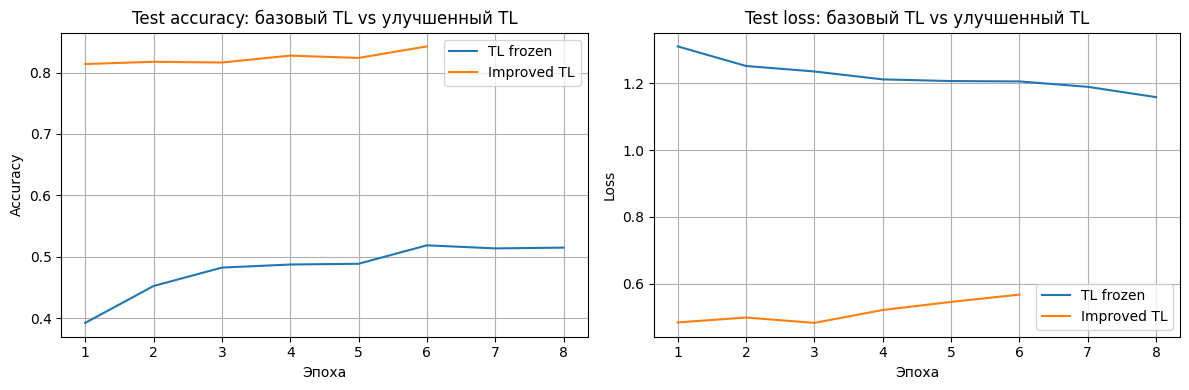

In [ ]:
imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std = (0.229, 0.224, 0.225)

train_transform_ft = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

test_transform_ft = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

full_train_ft = datasets.CIFAR10(root=str(data_root), train=True, download=False, transform=train_transform_ft)
full_test_ft = datasets.CIFAR10(root=str(data_root), train=False, download=False, transform=test_transform_ft)

train_subset_ft, _ = subset_by_classes(full_train_ft, selected_class_indices, max_per_class=max_train_per_class)
test_subset_ft, _ = subset_by_classes(full_test_ft, selected_class_indices, max_per_class=max_test_per_class)

train_loader_ft = DataLoader(train_subset_ft, batch_size=32, shuffle=True, num_workers=0)
test_loader_ft = DataLoader(test_subset_ft, batch_size=32, shuffle=False, num_workers=0)

model_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model_ft.parameters():
    param.requires_grad = False

for param in model_ft.layer4.parameters():
    param.requires_grad = True

model_ft.fc = nn.Linear(model_ft.fc.in_features, num_target_classes)
model_ft = model_ft.to(device)

optimizer_ft = torch.optim.Adam([
    {"params": model_ft.layer4.parameters(), "lr": 1e-4},
    {"params": model_ft.fc.parameters(), "lr": 1e-3},
])

num_epochs_ft = 6
history_ft = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, num_epochs_ft + 1):
    train_loss, train_acc = train_one_epoch_mapped(model_ft, train_loader_ft, optimizer_ft, criterion, device)
    test_loss, test_acc = evaluate_mapped(model_ft, test_loader_ft, criterion, device)

    history_ft["train_loss"].append(train_loss)
    history_ft["train_acc"].append(train_acc)
    history_ft["test_loss"].append(test_loss)
    history_ft["test_acc"].append(test_acc)

    print(
        f"[Improved TL] Эпоха {epoch}/{num_epochs_ft}: "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
        f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}"
    )

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(np.arange(1, num_epochs_tl + 1), history_tl["test_acc"], label="TL frozen")
plt.plot(np.arange(1, num_epochs_ft + 1), history_ft["test_acc"], label="Improved TL")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Test accuracy: базовый TL vs улучшенный TL")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(np.arange(1, num_epochs_tl + 1), history_tl["test_loss"], label="TL frozen")
plt.plot(np.arange(1, num_epochs_ft + 1), history_ft["test_loss"], label="Improved TL")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Test loss: базовый TL vs улучшенный TL")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

y_true_ft, y_pred_ft = collect_predictions(model_ft, test_loader_ft, device)
cm_ft = confusion_matrix(y_true_ft, y_pred_ft)

plt.figure(figsize=(6, 5))
plt.imshow(cm_ft, cmap="Blues")
plt.title("Confusion matrix — improved TL")
plt.colorbar()
plt.xticks(range(num_target_classes), [local_to_name[i] for i in range(num_target_classes)], rotation=45)
plt.yticks(range(num_target_classes), [local_to_name[i] for i in range(num_target_classes)])
plt.xlabel("Predicted")
plt.ylabel("True")
for i in range(cm_ft.shape[0]):
    for j in range(cm_ft.shape[1]):
        plt.text(j, i, cm_ft[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

print(classification_report(
    y_true_ft,
    y_pred_ft,
    target_names=[local_to_name[i] for i in range(num_target_classes)]
))

## 9. Итоговые выводы по лабораторной

В заключение сформулируйте короткое резюме (5–8 предложений):
- в каких случаях вы после этой работы **в первую очередь** будете пробовать transfer learning и почему;
- когда, по вашему мнению, имеет смысл всё-таки обучать модель с нуля (и зачем);
- какие настройки (заморозка слоёв, lr, число эпох, размер подвыборки) вы считаете для себя "разумными по умолчанию" после проведённых экспериментов.

Пишите так, чтобы вы сами, открыв этот ноутбук через полгода, смогли быстро вспомнить, что вы поняли про transfer learning.


In [ ]:
final_summary = f"""После этой лабораторной я бы в первую очередь пробовал transfer learning в тех задачах, где данных немного, а сама архитектура уже хорошо себя показала на большом внешнем датасете. 
Эксперимент показал, что предобученная сеть обычно быстрее выходит на разумное качество, чем обучение с нуля, особенно если речь идёт о сравнительно небольшом подмножестве изображений. 
При этом я для себя отдельно отметил, что простой вариант «заморозить всё и переобучить только последний слой» — это хороший старт, но не всегда финальное решение. 
Если графики быстро выходят на плато, это сигнал, что модели не хватает гибкости и стоит попробовать partial fine-tuning верхних блоков. 
Также важно помнить о соответствии входных данных условиям предобучения: для ImageNet-моделей размер и предобработка изображений имеют значение. 
На практике мой рабочий порядок теперь такой: сначала запустить frozen-backbone baseline, затем посмотреть на кривые loss/accuracy, а после этого при необходимости разморозить часть сети и подобрать разные learning rate для backbone и head. 
Обучение полностью с нуля я бы оставлял либо для случаев с большим объёмом данных, либо когда домен слишком далёк от ImageNet и преимущества предобучения почти не проявляются. 
В целом transfer learning для меня после этой работы выглядит как самый рациональный первый шаг для реальной прикладной задачи компьютерного зрения."""

print(final_summary)